<a href="https://colab.research.google.com/github/hjiwoong/ML/blob/main/Chapter04_%E1%84%87%E1%85%AE%E1%86%AB%E1%84%85%E1%85%B2_(3)_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving NanumGothic.ttf to NanumGothic.ttf


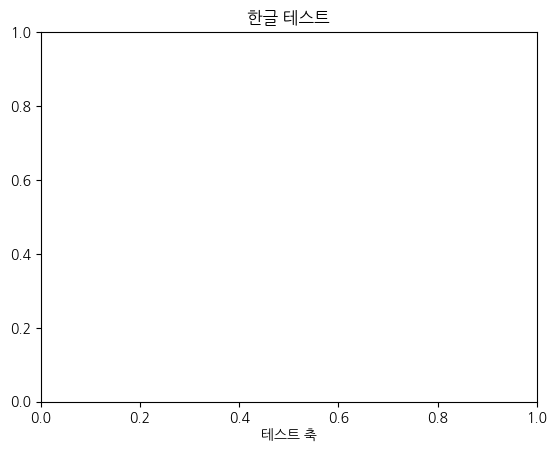

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

In [ ]:
#통합 평가 함수
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test,pred)
    accuracy = accuracy_score(y_test,pred)
    precision = precision_score(y_test,pred)
    recall = recall_score(y_test,pred)
    f1 = f1_score(y_test,pred)
    roc_auc = roc_auc_score(y_test,pred_proba)

    print('오차행렬')
    print(confusion)
    print(f'정확도:{accuracy:.4f}, 정밀도:{precision:.4f}, 재현율:{recall:2.4f}, F1:{f1:3.4f}, AUC:{roc_auc:4.4f}')

In [ ]:
#모델 학습/예측/평가 통합 함수
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
  model.fit(ftr_train, tgt_train)
  pred = model.predict(ftr_test)
  pred_proba = model.predict_proba(ftr_test)[:,1]
  get_clf_eval(tgt_test, pred, pred_proba)

### 신용카드 사기 검출
- 이상탐지(Anomaly Detection)

In [ ]:
#데이터 로딩
card_df = pd.read_csv('/content/drive/MyDrive/KWU/ML/Data/creditcard.csv')
print('데이터 크기:',card_df.shape)
print('컬럼:',list(card_df.columns))
card_df.head(3)

데이터 크기: (284807, 31)
컬럼: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [ ]:
#레이블 불균형 확인, Class : 레이블 (0=정상, 1=사기)
print('레이블 분포:')
print(card_df['Class'].value_counts())
print('사기 비율:',round(card_df['Class'].mean()*100,4),'%')

레이블 분포:
Class
0    284315
1       492
Name: count, dtype: int64
사기 비율: 0.1727 %


In [ ]:
#STEP 1: 기본 전처리 - Time 컬럼만 제거
from sklearn.linear_model import LogisticRegression
def get_preprocessed_df(df=None):
  df_copy = df.copy()
  df_copy.drop('Time',axis=1,inplace=True)
  return df_copy
def get_train_test_dataset(df=None):
  df_copy = get_preprocessed_df(df)
  X_features = df_copy.iloc[:,:-1]
  y_target = df_copy.iloc[:,-1]

  X_train, X_test, y_train, y_test = train_test_split(
      X_features, y_target, test_size=0.3, random_state=0, stratify=y_target
  )
  return X_train, X_test, y_train, y_test

#데이터 분할 및 불균형 비율 확인
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)
print(f'학습 데이터 사기 비율: {y_train.mean() * 100:.4f}%')
print(f'테스트 데이터 사기 비율: {y_test.mean() * 100:.4f}%')

#로지스틱 회귀 기본 평가 (아무 처리 없는 베이스라인)
lr_clf = LogisticRegression(max_iter = 1000) #max_iter: 최적화 알고리즘 경사 하강법(Gradient Descent)의 최대 반복 횟
lr_clf.fit(X_train,y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:,1]
get_clf_eval(y_test, lr_pred, lr_pred_proba)

학습 데이터 사기 비율: 0.1725%
테스트 데이터 사기 비율: 0.1732%
오차행렬
[[85281    14]
 [   57    91]]
정확도:0.9992, 정밀도:0.8667, 재현율:0.6149, F1:0.7194, AUC:0.9741


In [ ]:
#LightGBM 기본 평가 - 사기 검출처럼 복잡한 패턴이 있는 데이터에서 트리 모델이 유리한 경우가 많음
from lightgbm import LGBMClassifier
lgbm_clf = LGBMClassifier(
    n_estimators=1000,
    num_leaves=64, #리프 노드 수 기본값31
    n_jobs=-1,
    boost_from_average=False #0에서 시작, 불균형 데이터셋에서 소수 클래스 탐지 유리, 재현율을 개선하는데 기여
)
get_model_train_eval(lgbm_clf,ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)


[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

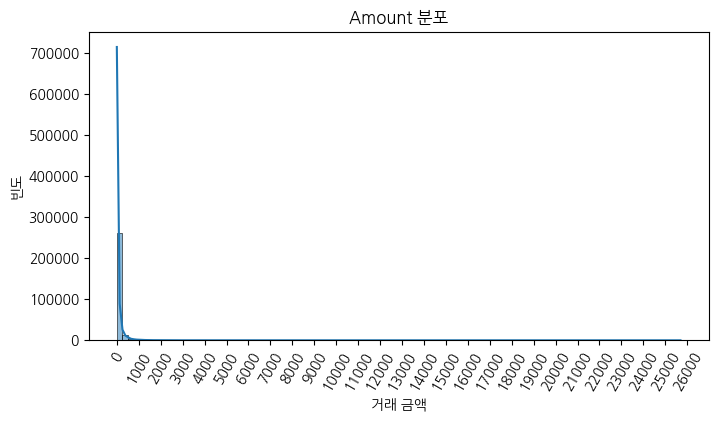

In [ ]:
#STEP 2: Amount 피처 전처리
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(8,4))
plt.xticks(range(0,30000,1000),rotation=60)
sns.histplot(card_df['Amount'],bins=100, kde=True)
plt.title('Amount 분포')
plt.xlabel('거래 금액')
plt.ylabel('빈도')
plt.show()
#오른쪽으로 치우친 왜도 분포 (정규화 필요)

In [ ]:
#STEP 2-A: StandardScaler로 Amount 표준화(평균=0, 표준편차=1)
#효과: 피처 간 스케일 차이 제거 -> 경사하강법 기반 모델(로지스틱 회귀) 성능 향상
#주의: 왜도는 제거되지 않음 (분포 형태는 유지, 범위만 변환)
def get_preprocessed_df(df=None):
  df_copy = df.copy()
  scaler = StandardScaler()

  amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))
  df_copy.insert(0,'Amount_Scaled',amount_n)

  df_copy.drop(['Time','Amount'],axis=1,inplace=True)
  return df_copy

#데이터 재분할(새 전처리 함수 반영)
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('[STEP2-A] StandardScaler 적용 - 로지스틱 회귀')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf,ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print('[STEP2-A] StandardScaler 적용 - LightGBM')
lgbm_clf = LGBMClassifier(
    n_estimators=1000,
    num_leaves=64,
    n_jobs=-1,
    boost_from_average=False
)
get_model_train_eval(lgbm_clf,ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

[STEP2-A] StandardScaler 적용 - 로지스틱 회귀
오차행렬
[[85281    14]
 [   55    93]]
정확도:0.9992, 정밀도:0.8692, 재현율:0.6284, F1:0.7294, AUC:0.9706
[STEP2-A] StandardScaler 적용 - LightGBM
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.080609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

In [ ]:
# STEP 2-B: np.loglp 로그 변환
# StandardScaler보다 왜도 제거 효과 강함, 오른쪽 치우친(right-skewed) 분포를 정규 분포에 가깝게 변환

# STEP 2-A: StandarScaler로 Amount 표준화 (평균=0, 표준편차=1)
# 효과: 피처 간 스케일 차이 제거 -> 경사하강법 기반 모델(로지스틱 회귀) 성능 향상
# 주의: 왜도는 제거되지 않음 (분포 형태는 유지, 범위만 변환)

def get_preprocessed_df(df=None):
  df_copy = df.copy()

  amount_n = np.log1p(df_copy['Amount'])
  df_copy.insert(0, 'Amount_Scaled', amount_n)

  df_copy.drop(['Time'], axis=1, inplace=True)
  return df_copy

# 데이터 재분할 (새 전처리 함수 반영)
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('[STEP2-B] 로그 변환 적용 - 로지스틱 회귀')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, X_train, X_test, y_train, y_test)

print('[STEP2-B] 로그 변환 적용 - LightGBM')
lgbm_clf = LGBMClassifier(
    n_estimators=1000,
    num_leaves=64,
    n_jobs=-1,
    boost_from_average=False
)
get_model_train_eval(lgbm_clf, X_train, X_test, y_train, y_test)
#정확도:0.9995, 정밀도:0.9576,재현율:0.7635,F1:0.8496,AUC:0.9796

[STEP2-B] 로그 변환 적용 - 로지스틱 회귀
오차행렬
[[85282    13]
 [   60    88]]
정확도:0.9991, 정밀도:0.8713, 재현율:0.5946, F1:0.7068, AUC:0.9761
[STEP2-B] 로그 변환 적용 - LightGBM
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

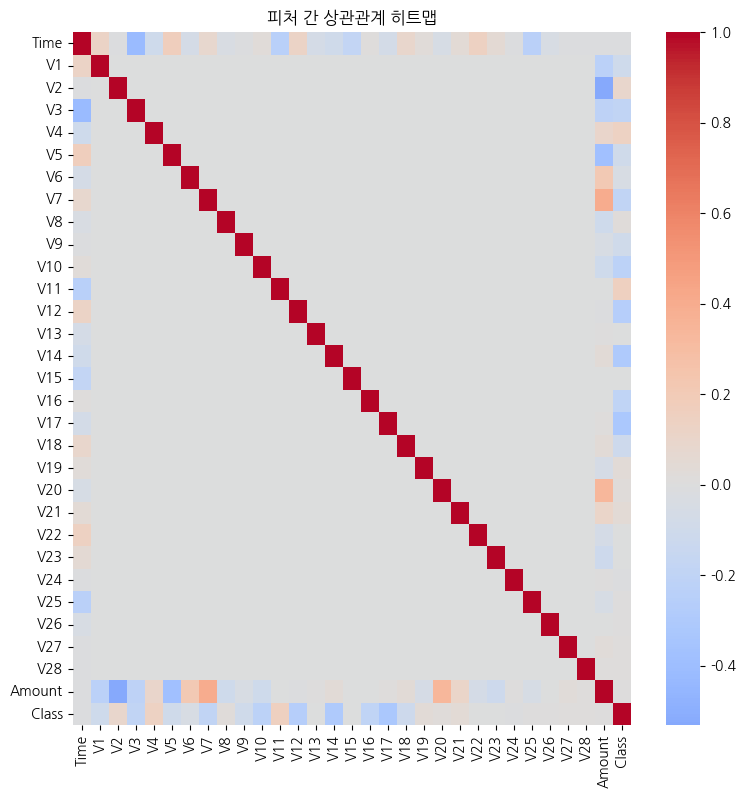

In [ ]:
#STEP 3: 이상치 제거 - 상관관계 히트맵으로 핵심 피치 파악
plt.figure(figsize=(9,9))
corr = card_df.corr() #피어슨 상관계수 계산
sns.heatmap(
    corr, cmap='coolwarm', center=0, annot=False
)
plt.title('피처 간 상관관계 히트맵')
plt.show()

In [ ]:
#Class와의 상관관계만 추출해서 정렬
class_corr = card_df.corr()['Class'].sort_values()
print(class_corr)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


In [ ]:
#IQR 기반 이상치 감지 함수
def get_outlier(df=None, column=None, weight=1.5):
  fraud = df[df['Class'] == 1][column] #사기 거래만 필터링
  q25 = np.percentile(fraud.values,25) #Q1
  q75 = np.percentile(fraud.values,75) #Q3
  iqr = q75 - q25 #IQR
  iqr_weight = iqr * weight
  #정상 범위: [Q1 - 1.5 X IQR, Q3 + 1.5 X IQR]
  lowest_val = q25 - iqr_weight
  highest_val = q75 + iqr_weight
  #정상 범위를 벗어난 인덱스 추출
  outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
  print(f'Q1:{q25:.2f}, Q3:{q75:.2f}, IQR:{iqr:.2f}')
  print(f'정상 범위: [{lowest_val:.2f}, {highest_val:.2f}]')
  return outlier_index

outlier_index = get_outlier(df=card_df, column='V14',weight=1.5)
print(f'이상치 인덱스: {list(outlier_index)}')
print(f'이상치 개수: {len(outlier_index)}건')
print(f' -> 전체 {len(card_df)}건 중 {len(outlier_index)}건 제거 예정')

Q1:-9.69, Q3:-4.28, IQR:5.41
정상 범위: [-17.81, 3.83]
이상치 인덱스: [8296, 8615, 9035, 9252]
이상치 개수: 4건
 -> 전체 284807건 중 4건 제거 예정


In [ ]:
#STEP 3: 이상치 제거 후 전처리 함수 업데이트
def get_preprocessed_df(df=None):
  df_copy = df.copy()

  amount_n = np.log1p(df_copy['Amount'])
  df_copy.insert(0,'Amount_Scaled',amount_n)
  df_copy.drop(['Time','Amount'],axis=1,inplace=True)

  #V14 이상치 제거
  outlier_index = get_outlier(df=df_copy, column='V14',weight=1.5)
  df_copy.drop(outlier_index,axis=0,inplace=True)

  return df_copy

#데이터 재분할(새 전처리 함수 반영)
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('[STEP3] 이상치 제거 후 - 로지스틱 회귀')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf,X_train,X_test, y_train,y_test)

print('[STEP3] 이상치 제거 후 - LightGBM')
lgbm_clf = LGBMClassifier(
    n_estimators=1000,
    num_leaves=64,
    n_jobs=-1,
    boost_from_average=False
)
get_model_train_eval(lgbm_clf,X_train, X_test, y_train, y_test)

Q1:-9.69, Q3:-4.28, IQR:5.41
정상 범위: [-17.81, 3.83]
[STEP3] 이상치 제거 후 - 로지스틱 회귀
오차행렬
[[85280    15]
 [   48    98]]
정확도:0.9993, 정밀도:0.8673, 재현율:0.6712, F1:0.7568, AUC:0.9725
[STEP3] 이상치 제거 후 - LightGBM
[LightGBM] [Info] Number of positive: 342, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047725 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199362, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [ ]:
#STEP 4: SMOTE 오버 샘플링
from imblearn.over_sampling import SMOTE #pip install imbalanced-learn

smote = SMOTE(random_state=0)
#SMOTE는 반드시 학습 데이터에만 적용
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 후:')
print(f"X_train_over: {X_train_over.shape}, y_train_over: {y_train_over.shape}")
print(f" 사기 비용: {y_train_over.mean()*100:.1f}%")
print('레이블 분포 (SMOTE 후):')
print(pd.Series(y_train_over).value_counts())
#0(정상)과 1(사기)이 1:1 비율로 균형 -> 불균형 문제 해소

SMOTE 적용 후:
X_train_over: (398040, 29), y_train_over: (398040,)
 사기 비용: 50.0%
레이블 분포 (SMOTE 후):
Class
0    199020
1    199020
Name: count, dtype: int64


In [ ]:
#STEP 4: SMOTE 적용 후 로지스틱 회귀 학습
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, X_train_over, X_test, y_train_over, y_test)

오차행렬
[[82933  2362]
 [   11   135]]
정확도:0.9722, 정밀도:0.0541, 재현율:0.9247, F1:0.1022, AUC:0.9736


In [ ]:
#STEP 4: SMOTE 적용 후 LightGBM
lgbm_clf = LGBMClassifier(
    n_estimators=1000,
    num_leaves=64,
    n_jobs=-1,
    boost_from_average=False
)
get_model_train_eval(lgbm_clf, X_train_over, X_test, y_train_over, y_test)

[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.146075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

KeyboardInterrupt: 

In [ ]:
#정밀도-재현율 곡선으로 최적 임계값 시각화
def precision_recall_curve_plot(y_test, pred_proba_c1):
  precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
  plt.figure(figsize=(8,6))
  n=thresholds.shape[0]
  #정밀도 곡선
  plt.plot(thresholds, precisions[0:n],
           linestyle='--',label = 'Precision(정밀도)',color='#3b82f6')
  #재현율 곡선
  plt.plot(thresholds, recalls[:n],
           label = 'Recall(재현율)',color='#ef4444')
  #두 곡선이 교차하는 지점의 임계값이 정밀도/재현율 균형점
  #사기 탐지 우선 -> 교차점보다 낮은 임계값 선택(재현율 높은 것)

  #교차점 찾기
  diff = precisions[:n] - recalls[:n]
  cross_idx = np.argmin(np.abs(diff)) #두 값의 차이가 가장 작은 인덱스
  cross_threshold = thresholds[cross_idx]
  cross_precision = precisions[cross_idx]
  cross_recall = recalls[cross_idx]
  cross_value = (cross_precision + cross_recall)/2
  #교차점 표시
  plt.scatter(cross_threshold, cross_value, color = 'green',s=100, zorder=5)
  plt.annotate(
      f'Threshold={cross_threshold:.2f}\nPrecision={cross_precision:.2f}\nRecall={cross_recall:.2f}',
      xy = (cross_threshold, cross_value),
      xytext = (cross_threshold+0.05, cross_value -0.1), #텍스트 위치 오프셋
      fontsize=9,
      color = 'green',
      arrowprops = dict(arrowstyle='->', color = 'green')
  )

  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start,end,0.1),2))
  plt.xlabel('Thershold(임계값)')
  plt.ylabel('precision/Recall')
  plt.title('임계값별 정밀도/재현율 변화\n(두 곡선의 교차점 = 균형 임계값)')
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()
precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:,1])
#